## Introduction to Recommender Systems

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
movies = pd.read_csv('movies.csv', delimiter=';', encoding='latin-1')

In [3]:
ratings = pd.read_csv('ratings.csv', delimiter=';')

In [4]:
movies

,movieId,title,genres,Unnamed: 3
0,1,Toy Story (1995),Animation|Children's|Comedy,NaN
1,2,Jumanji (1995),Adventure|Children's|Fantasy,NaN
2,3,Grumpier Old Men (1995),Comedy|Romance,NaN
3,4,Waiting to Exhale (1995),Comedy|Drama,NaN
4,5,Father of the Bride Part II (1995),Comedy,NaN
...,...,...,...,...
3878,3948,Meet the Parents (2000),Comedy,NaN
3879,3949,Requiem for a Dream (2000),Drama,NaN
3880,3950,Tigerland (2000),Drama,NaN
3881,3951,Two Family House (2000),Drama,NaN


In [5]:
ratings

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [6]:
df = pd.merge(movies, ratings, on='movieId')

In [7]:
df

,movieId,title,genres,Unnamed: 3,userId,rating,timestamp
0,1,Toy Story (1995),Animation|Children's|Comedy,NaN,1,5,978824268
1,1,Toy Story (1995),Animation|Children's|Comedy,NaN,6,4,978237008
2,1,Toy Story (1995),Animation|Children's|Comedy,NaN,8,4,978233496
3,1,Toy Story (1995),Animation|Children's|Comedy,NaN,9,5,978225952
4,1,Toy Story (1995),Animation|Children's|Comedy,NaN,10,5,978226474
...,...,...,...,...,...,...,...
1000204,3952,"Contender, The (2000)",Drama|Thriller,NaN,5812,4,992072099
1000205,3952,"Contender, The (2000)",Drama|Thriller,NaN,5831,3,986223125
1000206,3952,"Contender, The (2000)",Drama|Thriller,NaN,5837,4,1011902656
1000207,3952,"Contender, The (2000)",Drama|Thriller,NaN,5927,1,979852537


In [8]:
df = df.drop(['Unnamed: 3', 'genres'], axis=1)

In [9]:
df

,movieId,title,userId,rating,timestamp
0,1,Toy Story (1995),1,5,978824268
1,1,Toy Story (1995),6,4,978237008
2,1,Toy Story (1995),8,4,978233496
3,1,Toy Story (1995),9,5,978225952
4,1,Toy Story (1995),10,5,978226474
...,...,...,...,...,...
1000204,3952,"Contender, The (2000)",5812,4,992072099
1000205,3952,"Contender, The (2000)",5831,3,986223125
1000206,3952,"Contender, The (2000)",5837,4,1011902656
1000207,3952,"Contender, The (2000)",5927,1,979852537


### Exploratory Data Analysis

In [11]:
df.columns

Index(['movieId', 'title', 'userId', 'rating', 'timestamp'], dtype='object')

In [12]:
df.groupby('title')['rating'].mean().sort_values(ascending=False).head()

title
Gate of Heavenly Peace, The (1995)    5.0
Song of Freedom (1936)                5.0
Smashing Time (1967)                  5.0
Follow the Bitch (1998)               5.0
One Little Indian (1973)              5.0
Name: rating, dtype: float64

In [13]:
df.groupby('title')['rating'].count().sort_values(ascending=False).head()

title
Star Wars                 11114
Star Trek                  5347
American Beauty (1999)     3428
Mission                    2840
Jurassic Park (1993)       2672
Name: rating, dtype: int64

In [14]:
ratings = pd.DataFrame(df.groupby('title')['rating'].mean())

In [16]:
ratings.head()

,rating
title,
"$1,000,000 Duck (1971)",3.027027
'Night Mother (1986),3.371429
'Til There Was You (1997),2.692308
"'burbs, The (1989)",2.910891
...And Justice for All (1979),3.713568


In [17]:
ratings['count'] = pd.DataFrame(df.groupby('title')['rating'].count())

In [18]:
ratings.head()

,rating,count
title,,
"$1,000,000 Duck (1971)",3.027027,37
'Night Mother (1986),3.371429,70
'Til There Was You (1997),2.692308,52
"'burbs, The (1989)",2.910891,303
...And Justice for All (1979),3.713568,199


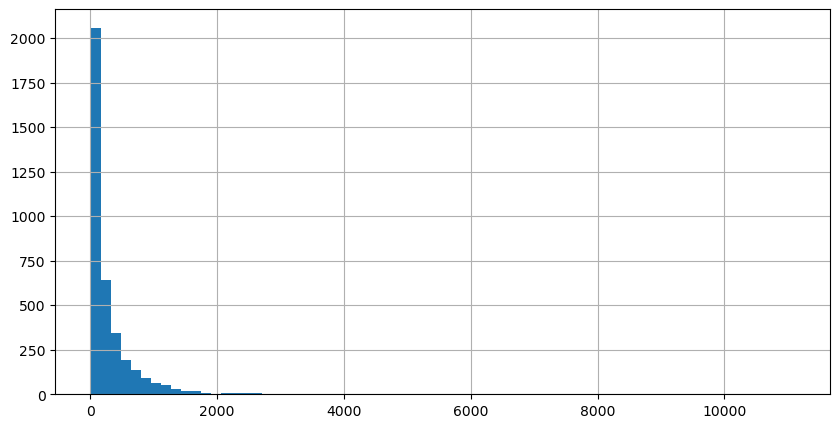

In [19]:
ratings['count'].hist(bins=70, figsize=(10,5));

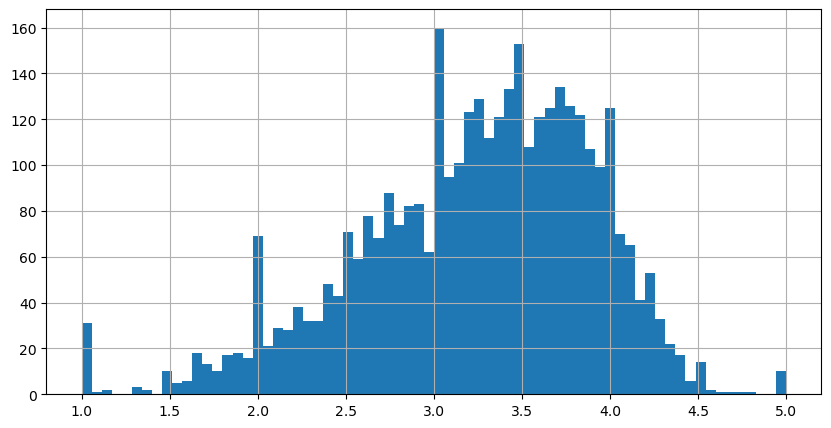

In [20]:
ratings['rating'].hist(bins=70, figsize=(10,5));

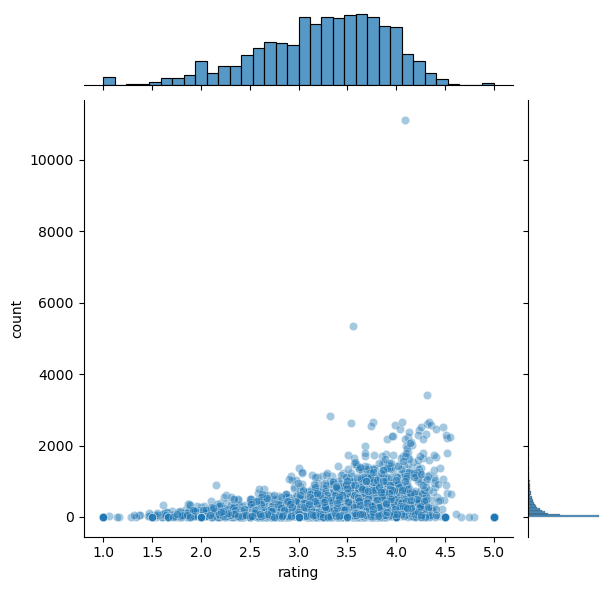

In [21]:
sns.jointplot(x='rating', y='count', data=ratings, alpha=0.4);

In [24]:
movies_mat = df.pivot_table(index='userId', columns='title', values='rating')

In [25]:
movies_mat

title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjærlighetens kjøtere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6036,NaN,3.0,NaN,NaN,NaN,NaN,2.0,4.0,NaN,NaN,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
6037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# Most rated movies

ratings.sort_values('count', ascending=False).head(10)

,rating,count
title,,
Star Wars,4.087367,11114
Star Trek,3.554704,5347
American Beauty (1999),4.317386,3428
Mission,3.323239,2840
Jurassic Park (1993),3.763847,2672
Saving Private Ryan (1998),4.337354,2653
Terminator 2,4.058513,2649
Austin Powers,3.535430,2639
"Matrix, The (1999)",4.315830,2590


In [35]:
starwars_user_rating = movies_mat['Star Wars']
park_user_rating = movies_mat['Jurassic Park (1993)']

In [36]:
similar_to_starwars = pd.DataFrame(movies_mat.corrwith(starwars_user_rating), columns=['correlation'])

In [37]:
similar_to_park = pd.DataFrame(movies_mat.corrwith(park_user_rating), columns=['correlation'])

In [38]:
similar_to_starwars.head()

,correlation
title,
"$1,000,000 Duck (1971)",0.214221
'Night Mother (1986),0.186430
'Til There Was You (1997),0.122292
"'burbs, The (1989)",0.029233
...And Justice for All (1979),0.150250


In [39]:
similar_to_park.head()

,correlation
title,
"$1,000,000 Duck (1971)",0.035806
'Night Mother (1986),0.185998
'Til There Was You (1997),0.109109
"'burbs, The (1989)",0.202455
...And Justice for All (1979),0.221315


In [40]:
similar_to_starwars.sort_values('correlation', ascending=False).head()

,correlation
title,
"War at Home, The (1996)",1.0
"Gay Deceivers, The (1969)",1.0
Hangmen Also Die (1943),1.0
"Truce, The (1996)",1.0
"I, Worst of All (Yo, la peor de todas) (1990)",1.0


In [41]:
similar_to_park.sort_values('correlation', ascending=False).head()

,correlation
title,
For the Moment (1994),1.0
I Got the Hook Up (1998),1.0
"Friend of the Deceased, A (1997)",1.0
Foreign Student (1994),1.0
Little Men (1998),1.0


In [42]:
corr_starwars = similar_to_starwars.join(ratings['count'])

In [46]:
corr_starwars[corr_starwars['count'] > 100].sort_values('correlation', ascending=False).head()

,correlation,count
title,,
Star Wars,1.000000,11114
Captain Horatio Hornblower (1951),0.455335,105
Dracula (1958),0.426787,102
Raiders of the Lost Ark (1981),0.410567,2514
Star Trek III,0.380935,927


In [44]:
corr_park = similar_to_park.join(ratings['count'])

In [47]:
corr_park[corr_park['count'] > 100].sort_values('correlation', ascending=False).head()

,correlation,count
title,,
Jurassic Park (1993),1.000000,2672
Lost World,0.522265,1255
"Dark Half, The (1993)",0.491516,102
"Fighting Seabees, The (1944)",0.460547,101
"Believers, The (1987)",0.445108,102
